In [1]:
import pandas as pd

df = pd.read_csv('data/raw/heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
df.shape

(918, 12)

In [3]:
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [4]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
df.describe(include='object')

/var/folders/rv/82qcynms6vscthmhjxmxktwm0000gn/T/ipykernel_13385/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


In [7]:
df['Cholesterol'].value_counts().head(10)

Cholesterol
0      172
254     11
223     10
220     10
211      9
204      9
230      9
216      9
260      8
246      8
Name: count, dtype: int64

In [8]:
df[df['RestingBP'] == 0].shape

(1, 12)

In [9]:
#The following keeps every row except the one where RestingBP is zero.

In [10]:
df = df[df['RestingBP'] != 0]

In [11]:
#The following cell calculates the median for Cholesterol after removing all those zero values, and then replaces all the zero values for Cholesterol in the df with this median

In [12]:
median_cholesterol = df[df['Cholesterol'] != 0]['Cholesterol'].median()
df['Cholesterol'] = df['Cholesterol'].replace(0, median_cholesterol)

In [13]:
#Let's just make surethose zeros have been replaced successfully

In [14]:
df['Cholesterol'].value_counts().head(10)

Cholesterol
237    177
254     11
223     10
220     10
211      9
204      9
230      9
216      9
260      8
246      8
Name: count, dtype: int64

In [15]:
#So that looks good. No more zeros. Now let's plot the original data against the new cleaned Cholesterol data and see what the effect is on some of its aspects.
#First we reload the original data but name the new df accordingly

In [16]:
df_original = pd.read_csv('data/raw/heart.csv')

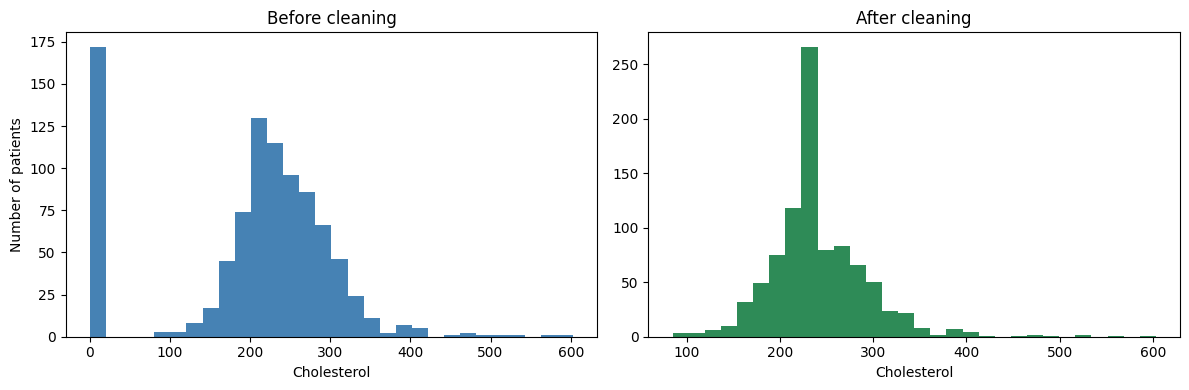

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_original['Cholesterol'], bins=30, color='steelblue')
axes[0].set_title('Before cleaning')
axes[0].set_xlabel('Cholesterol')
axes[0].set_ylabel('Number of patients')

axes[1].hist(df['Cholesterol'], bins=30, color='seagreen')
axes[1].set_title('After cleaning')
axes[1].set_xlabel('Cholesterol')

plt.tight_layout()
plt.show()

In [18]:
# Nice, so the cleaning has given us a nice distribution on Cholesterol and no spike at zero.
# Now let's encode the categorical columns in our df, so that python will knopw what to do with the data in those columns.

In [19]:
#First let's see what's in those columns by printing the unique data in them

In [20]:
cat_columns = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in cat_columns:
    print(col, df[col].unique())

Sex <StringArray>
['M', 'F']
Length: 2, dtype: str
ChestPainType <StringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str
RestingECG <StringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str
ExerciseAngina <StringArray>
['N', 'Y']
Length: 2, dtype: str
ST_Slope <StringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str


In [21]:
#there are two main encoding approaches and which one you use depends on the column:
#Label encoding — replaces each category with a number. Male → 0, Female → 1. Simple, but implies an order that doesn't always exist.
#One-hot encoding — creates a new column for each category containing 0 or 1. More correct for categories with no natural order, but creates more columns.

In [22]:
#Sex and ExerciseAngina are straightforward binary columns — just two options each, so simple label encoding is fine. There's no implied order to worry about.
#ChestPainType, RestingECG, and ST_Slope have 3 or 4 categories with no natural numerical order, so one-hot encoding is the more correct approach.

In [23]:
#The following will show us what the Sex columns looks like at this point

In [24]:
print(df['Sex'].value_counts())
print(repr(df['Sex'].iloc[0]))

Sex
M    724
F    193
Name: count, dtype: int64
'M'


In [25]:
df['Sex'] = df['Sex'].map({'M':1, 'F':0})
df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y':1, 'N':0})

In [26]:
#print the unique entries for those two columns now and see if th encoding worked for the binary labels

In [27]:
print(df['Sex'].unique())
print(df['ExerciseAngina'].unique())

[1 0]
[0 1]


In [28]:
#the output here suggests that the mapping didn't find any matches. We run the following to see what the raw representation of the first value is, which will show any spaces for example.

In [29]:
print(repr(df['Sex'].iloc[0]))

np.int64(1)


In [30]:
#the problem here may be related to pandas string handling. Let's see what is actually in the df column Sex right now

In [31]:
print(df['Sex'].value_counts())

Sex
1    724
0    193
Name: count, dtype: int64


In [32]:
print(repr(df['Sex'].iloc[1]))

np.int64(0)


In [33]:
# Now we use one-hot encoding to encode the ChestPainType, RestingECG, and ST_Slope columns. One-hot encoding uses the built-in pandas function get_dummies() with the following arguments
#The dtype=int just ensures the new columns contain 0 and 1 as integers rather than True/False booleans.

In [34]:
df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], dtype = int)

In [35]:
#Let's now check the result

In [36]:
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1


In [37]:
#The df will now have a few more columns...

In [38]:
df.shape

(917, 19)

A quick and dirty first attempt at a heatmap
df.corr() calculates the correlation between every pair of columns — the result is a number between -1 and 1.
annot=True means each comparison is annoted with its value
fmt='.2f' means these values are given to 2 dec places
cmap='coolwarm' means -ve values are blue and more +ve values are red
centre=0 means those closer to 0 are more white

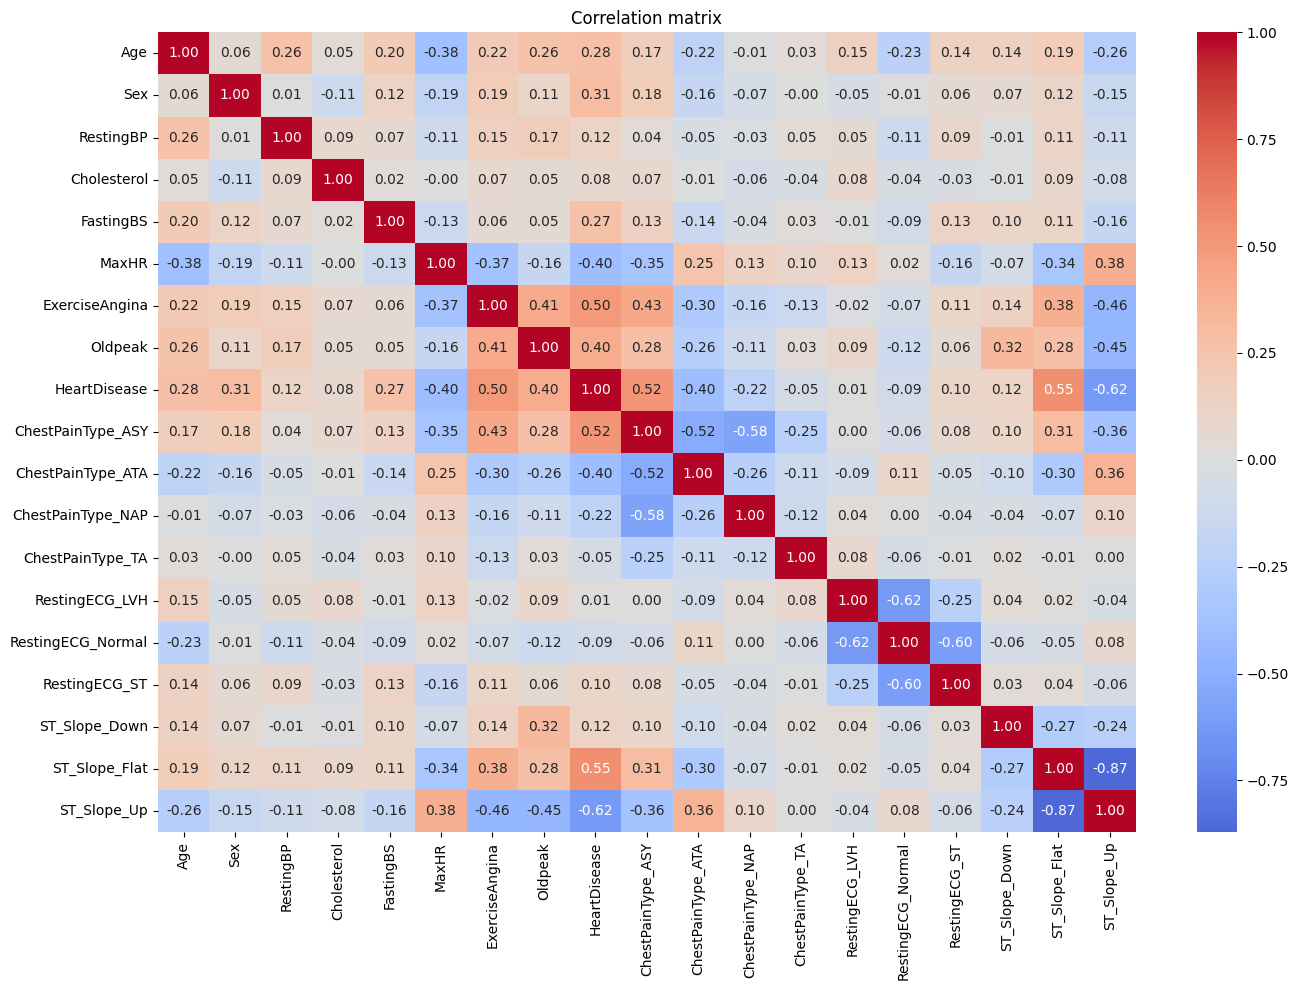

In [39]:
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

Now to save the cleaned data

In [40]:

df.to_csv('data/processed/heart_cleaned.csv', index=False)